In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

print("Fake news dataset:")
display(fake.head())

print("Real news dataset:")
display(true.head())

Fake news dataset:


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


Real news dataset:


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [3]:
print("Fake news shape:", fake.shape)
print("Real news shape:", true.shape)

print("\nMissing values in Fake news:")
print(fake.isnull().sum())

print("\nMissing values in Real news:")
print(true.isnull().sum())

Fake news shape: (23481, 4)
Real news shape: (21417, 4)

Missing values in Fake news:
title      0
text       0
subject    0
date       0
dtype: int64

Missing values in Real news:
title      0
text       0
subject    0
date       0
dtype: int64


In [4]:
fake["label"] = 0
true["label"] = 1

print("Fake news label:")
print(fake["label"].value_counts())

print("\nReal news label:")
print(true["label"].value_counts())

Fake news label:
label
0    23481
Name: count, dtype: int64

Real news label:
label
1    21417
Name: count, dtype: int64


In [5]:
data = pd.concat([fake, true], ignore_index=True)

print("Combined dataset shape:", data.shape)
print("\nLabel distribution:")
print(data["label"].value_counts())

Combined dataset shape: (44898, 5)

Label distribution:
label
0    23481
1    21417
Name: count, dtype: int64


In [6]:
data["content"] = data["title"] + " " + data["text"]

data = data[["content", "label"]]

data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print(data.head())
print("\nDataset shape:", data.shape)

                                             content  label
0  Ben Stein Calls Out 9th Circuit Court: Committ...      0
1  Trump drops Steve Bannon from National Securit...      1
2  Puerto Rico expects U.S. to lift Jones Act shi...      1
3   OOPS: Trump Just Accidentally Confirmed He Le...      0
4  Donald Trump heads for Scotland to reopen a go...      1

Dataset shape: (44898, 2)


In [7]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data["content"] = data["content"].apply(clean_text)

print(data.head())

                                             content  label
0  ben stein calls out th circuit court committed...      0
1  trump drops steve bannon from national securit...      1
2  puerto rico expects us to lift jones act shipp...      1
3  oops trump just accidentally confirmed he leak...      0
4  donald trump heads for scotland to reopen a go...      1


In [8]:
from sklearn.model_selection import train_test_split

X = data["content"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (35918,)
Testing data: (8980,)


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (35918, 5000)
Testing TF-IDF shape: (8980, 5000)


In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model trained successfully!")

Model trained successfully!


In [11]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9896436525612472

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [12]:
news = input("Enter a news article: ")

cleaned_news = clean_text(news)
news_tfidf = vectorizer.transform([cleaned_news])

prediction = model.predict(news_tfidf)[0]

if prediction == 0:
    print("Prediction: FAKE NEWS")
else:
    print("Prediction: REAL NEWS")

Prediction: FAKE NEWS


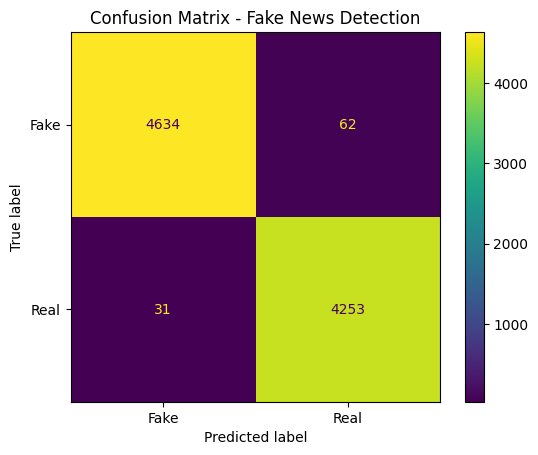

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

disp.plot()
plt.title("Confusion Matrix - Fake News Detection")
plt.show()

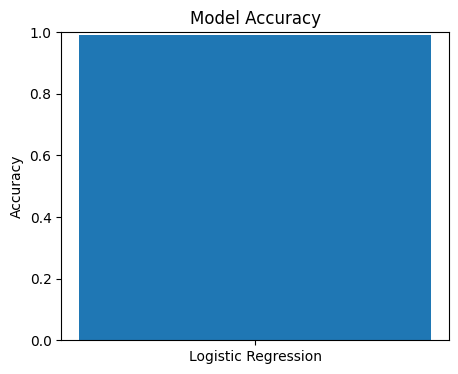

Model Accuracy: 98.96%


In [14]:
accuracy = accuracy_score(y_test, y_pred)

plt.figure(figsize=(5, 4))
plt.bar(["Logistic Regression"], [accuracy])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.show()

print(f"Model Accuracy: {accuracy * 100:.2f}%")

## Conclusion

The Fake News Detection system was successfully developed using Machine Learning. 
The dataset was cleaned and preprocessed using text processing techniques, and TF-IDF 
was used to convert news text into numerical features. Logistic Regression was then 
trained to classify news as Fake or Real.

The model achieved an accuracy of approximately 98.96% on the test dataset. The system 
can also predict whether newly entered news content is likely to be Fake or Real.

This project demonstrates how Machine Learning and Natural Language Processing can be 
used for automated news classification.

In [15]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [16]:
news = input("Enter a news article: ")

cleaned_news = clean_text(news)
news_tfidf = vectorizer.transform([cleaned_news])

prediction = model.predict(news_tfidf)[0]

In [17]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
